# Analytic disk

We create a Magritte model from an analytic description of a Keplerian disk (see e.g. [Homan et al. 2018](https://doi.org/10.1051/0004-6361/201732246); [Booth et al. 2019](https://doi.org/10.1051/0004-6361/201834388)).

## Setup

Import the required functionalty.

In [1]:
import magritte.setup    as setup                   # Model setup
import magritte.core     as magritte                # Core functionality
import magritte.mesher   as mesher                  # Mesher
import numpy             as np                      # Data structures
import warnings                                     # Hide warnings
warnings.filterwarnings('ignore')                   # especially for yt
import yt                                           # 3D plotting
import os

from tqdm                import tqdm                # Progress bars
from astropy             import units, constants    # Unit conversions
from scipy.spatial       import Delaunay, cKDTree   # Finding neighbors
from yt.funcs            import mylog               # To avoid yt output 
mylog.setLevel(40)                                  # as error messages

Define a working directory (you will have to change this; it must be an **absolute path**).

In [2]:
wdir = "/ammonia_hfs/Magritte/testing/"

Create the working directory.

In [3]:
!mkdir -p $wdir

Define file names.

In [4]:
model_file = os.path.join(wdir, 'model_analytic_spheres_nh3.hdf5')   # Resulting Magritte model
lamda_file = os.path.join(wdir, 'p-nh3@loreau.dat.txt'                  )   # Line data file
bmesh_name = os.path.join(wdir, 'analytic_disk'           )   # bachground mesh name (no extension!)

We use a data file that can be downloaded with the following links.

In [5]:
lamda_link = "https://home.strw.leidenuniv.nl/~moldata/datafiles/p-nh3@loreau.dat"

Dowload the snapshot and the linedata (``%%capture`` is just used to suppress the output).

In [6]:
%%capture
#!wget $lamda_link --output-document $lamda_file

## Model parameters

The functions below describe the disk structure, based on the Magritte application presented in [De Ceuster et al. (2019)](https://doi.org/10.1093/mnras/stz3557).

In [7]:
import numpy as np
from scipy import constants

# Fixed (reproducible) random seed
NH3_SEED = 12345
rng = np.random.default_rng(NH3_SEED)

# Sphere parameters
n_spheres = 2000
sphere_radius_au = 50
big_radius_au = 1000

# Convert units
sphere_radius = sphere_radius_au * constants.au
big_radius = big_radius_au * constants.au
r_out = big_radius
r_in = 10 * constants.au
# Random center positions (within the big sphere)
centers = []
while len(centers) < n_spheres:
    pos = rng.uniform(-big_radius, big_radius, 3)
    if np.linalg.norm(pos) + sphere_radius < big_radius:
        centers.append(pos)
centers = np.array(centers)

# Generate a random velocity **direction** for each sphere
random_directions = rng.normal(size=(n_spheres,3))
random_directions /= np.linalg.norm(random_directions, axis=1)[:, np.newaxis]  # Normalize

speed = 2e2  # 0.2 km/s = 200 m/s

sphere_velocities = random_directions * speed  # Each sphere has [vx, vy, vz] with magnitude 200 m/s

# Physics constants/parameters
G = constants.G
kb = constants.k
m_H2 = 2.01588 * constants.u
XNH3 = 6.0e-8
vturb = 50
T_cloud = 50
rho_cloud = 1.0E5 * 1.0E6 * m_H2

def inside_any_sphere(rr):
    # Returns (True, i) if inside sphere i; else (False, None)
    diffs = centers - rr
    dists = np.linalg.norm(diffs, axis=1)
    for i, d in enumerate(dists):
        if d < sphere_radius:
            return True, i
    return False, None

def density(rr):
    rho_0 = rho_cloud  # central density in si units
    r_0 = r_in # inner flat part radius in AU
    alpha = 0   # power-law index
    r_max = r_out  # outer cutoff radius in AU

    # Compute radial distance
    Radius = (rr[0]**2. + rr[1]**2. + rr[2]**2.)**0.5

    # Calculate density profile
    GasDensity = rho_0 / (1.0 + (Radius / r_0)**alpha)

    # Apply cutoff beyond r_out
    if hasattr(Radius, "__len__"):
        GasDensity[Radius > r_max] = 0.0
    else:
        if Radius > r_max:
            GasDensity = 0.0

    return GasDensity

def abn_nH2(rr):
    # Only H2 everywhere
    return density(rr) / (2.01588 * constants.u)

def abn_nNH3(rr):
    # Only present if inside any ammonia sphere
    inside, _ = inside_any_sphere(rr)
    if inside:
        return XNH3 * abn_nH2(rr)
    else:
        return 0.0

def temperature(rr):
    return T_cloud

def turbulence(rr):
    return (vturb/constants.c)**2

def velocity_f(rr):
    # If inside any sphere, return that sphere's velocity; otherwise zero
    inside, i = inside_any_sphere(rr)
    if inside:
        v = sphere_velocities[i]
    else:
        v = np.zeros(3)
    return v / 3e8  # Fraction of c

# Save or print seed for reproducibility
print("NH3_SEED =", NH3_SEED)


NH3_SEED = 12345


## Create background mesh

Define the desired background mesh, a ($75 \times 75 \times 75$) cube.

In [8]:
resolution = 150

xs = np.linspace(-r_out*1.2, +r_out*1.2, resolution, endpoint=True)
ys = np.linspace(-r_out*1.2, +r_out*1.2, resolution, endpoint=True)
zs = np.linspace(-r_out*1.2, +r_out*1.2, resolution, endpoint=True)

(Xs, Ys, Zs) = np.meshgrid(xs, ys, zs)

# Extract positions of points in background mesh
position = np.array((Xs.ravel(), Ys.ravel(), Zs.ravel())).T

# Evaluate the density on the cube
rhos      = density([Xs, Ys, Zs])
rhos_min  = np.min(rhos[rhos!=0.0])
rhos     += rhos_min

Now we remesh this model using the new remesher

In [9]:
positions_reduced, nb_boundary = mesher.remesh_point_cloud(position, rhos.ravel(), max_depth=10, threshold= 2e-1, hullorder=4)

new interior points:  93508
number boundary points:  1538


We add a spherical inner boundary at 0.01*r_out

In [10]:
healpy_order = 5 #using healpy to determine where to place the 12*healpy_order**2 boundary points on the sphere
origin = np.array([0.0,0.0,0.0]).T #the origin of the inner boundary sphere
positions_reduced, nb_boundary = mesher.point_cloud_add_spherical_inner_boundary(positions_reduced, nb_boundary, 0.01*r_out, healpy_order=healpy_order, origin=origin)
print("number of points in reduced grid: ", len(positions_reduced))
print("number of boundary points: ", nb_boundary)

number of points in reduced grid:  95346
number of boundary points:  1838


We add a spherical outer boundary at r_out

In [11]:
healpy_order = 15 #using healpy to determine where to place the 12*healpy_order**2 boundary points on the sphere
origin = np.array([0.0,0.0,0.0]).T #the origin of the inner boundary sphere
positions_reduced, nb_boundary = mesher.point_cloud_add_spherical_outer_boundary(positions_reduced, nb_boundary, r_out, healpy_order=healpy_order, origin=origin)
print("number of points in reduced grid: ", len(positions_reduced))

number of points in reduced grid:  45477


In [12]:
npoints = len(positions_reduced)

# Extract Delaunay vertices (= Voronoi neighbors)
delaunay = Delaunay(positions_reduced)
(indptr, indices) = delaunay.vertex_neighbor_vertices
neighbors = [indices[indptr[k]:indptr[k+1]] for k in range(npoints)]
nbs       = [n for sublist in neighbors for n in sublist]
n_nbs     = [len(sublist) for sublist in neighbors]

# Convenience arrays
zeros = np.zeros(npoints)
ones  = np.ones (npoints)

Convert model functions to arrays based the model mesh.

In [13]:
position = positions_reduced
velocity = np.array([velocity_f (rr) for rr in positions_reduced])
nH2      = np.array([abn_nH2    (rr) for rr in positions_reduced])
nNH3      = np.array([abn_nNH3   (rr) for rr in positions_reduced])
tmp      = np.array([temperature(rr) for rr in positions_reduced])
trb      = np.array([turbulence (rr) for rr in positions_reduced])

## Create model

Now all data is read, we can use it to construct a Magritte model.

<div class="alert alert-warning">

Warning

Since we do not aim to do self-consistent non-LTE simulations in these examples, we only consider the first radiative transition of CO (J=1-0). To consider all transitions, use `setup.set_linedata_from_LAMDA_file` as in the commented line below it.
We also only consider 2 rays here (up and down the direction we want to image). To consider all directions, comment out the indecated lines and use `setup.set_uniform_rays` as in the commented line below.
    
</div>

In [14]:
model = magritte.Model ()                              # Create model object

model.parameters.set_model_name         (model_file)   # Magritte model file
model.parameters.set_dimension          (3)            # This is a 3D model
model.parameters.set_npoints            (npoints)      # Number of points
model.parameters.set_nrays              (2)            # Number of rays  
model.parameters.set_nspecs             (3)            # Number of species (min. 5)
model.parameters.set_nlspecs            (1)            # Number of line species
model.parameters.set_nquads             (51)           # Number of quadrature points

model.geometry.points.position.set(position)
model.geometry.points.velocity.set(velocity)

model.geometry.points.  neighbors.set(  nbs)
model.geometry.points.n_neighbors.set(n_nbs)

model.chemistry.species.abundance = np.array((nNH3, nH2, zeros)).T
model.chemistry.species.symbol    = ['p-NH3', 'H2', 'e-']

model.thermodynamics.temperature.gas  .set(tmp)
model.thermodynamics.turbulence.vturb2.set(trb)

model.parameters.set_nboundary(nb_boundary)
model.geometry.boundary.boundary2point.set(np.arange(nb_boundary))

direction = np.array([[+1,0,0], [-1,0,0]])            # Comment out to use all directions
model.geometry.rays.direction.set(direction)          # Comment out to use all directions
model.geometry.rays.weight   .set(0.5 * np.ones(2))   # Comment out to use all directions

# setup.set_uniform_rays            (model)   # Uncomment to use all directions
setup.set_boundary_condition_CMB  (model)
#setup.set_linedata_from_LAMDA_file(model, lamda_file, {'considered transitions': [0,1]})  # Consider only CO lines
setup.set_linedata_from_LAMDA_file(model, lamda_file)   # Consider all transitions
setup.set_quadrature              (model)

model.write()

Writing parameters...
Writing points...


Writing rays...
Writing boundary...
Writing chemistry...
Writing species...
Writing thermodynamics...
Writing temperature...
Writing turbulence...
Writing lines...
Writing lineProducingSpecies...
Writing linedata...
ncolpoar = 1
--- colpoar = 0
Writing collisionPartner...
(l, c) = 0, 0
Writing quadrature...
Writing populations...
Writing radiation...
Writing frequencies...


## Plot model

Load the data in a `yt` unstructured mesh.

In [15]:
ds = yt.load_unstructured_mesh(
    connectivity = delaunay.simplices.astype(np.int64),
    coordinates  = delaunay.points.astype(np.float64) * 100.0, # yt expects cm not m 
    node_data    = {('connect1', 'n'): nNH3[delaunay.simplices].astype(np.float64)}
)

Plot a slice through the mesh orthogonal to the z-axis and x-axis.


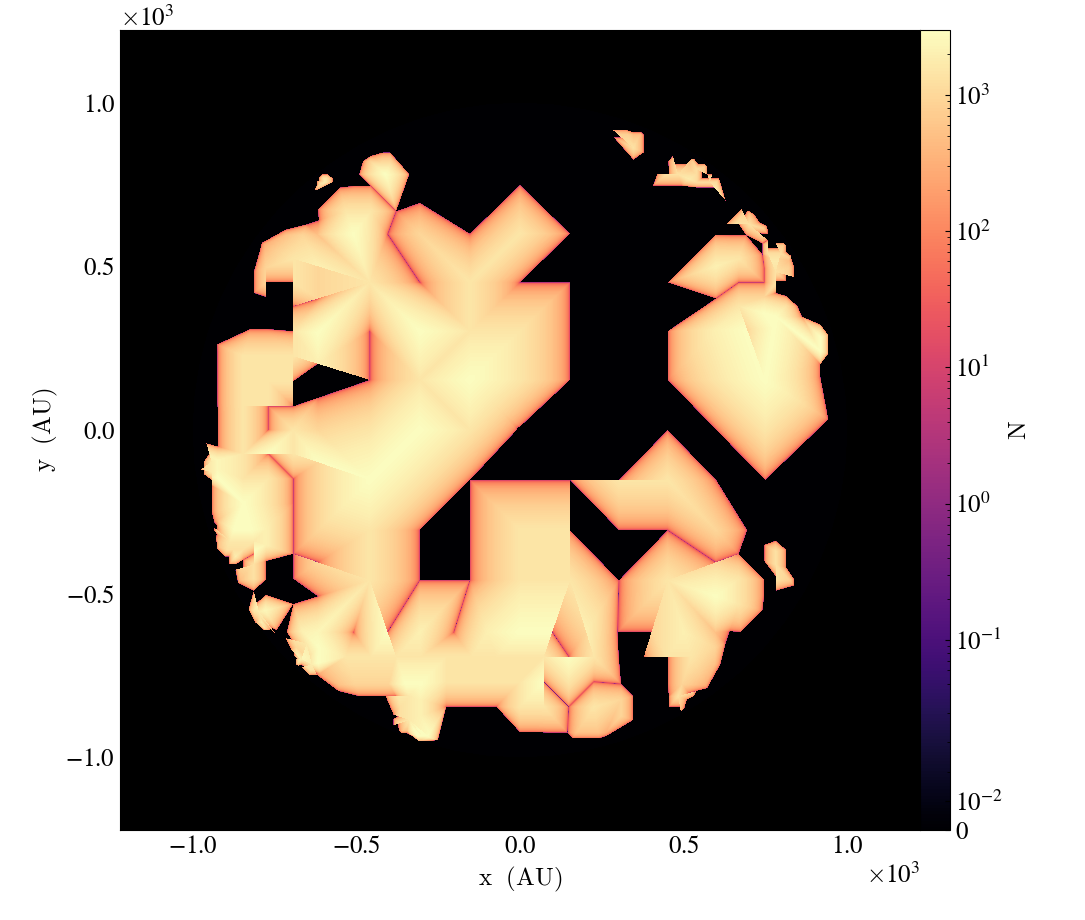

In [16]:
sl = yt.SlicePlot (ds, 'z', ('connect1', 'n'))
sl.set_cmap       (('connect1', 'n'), 'magma')
sl.zoom           (0.9)


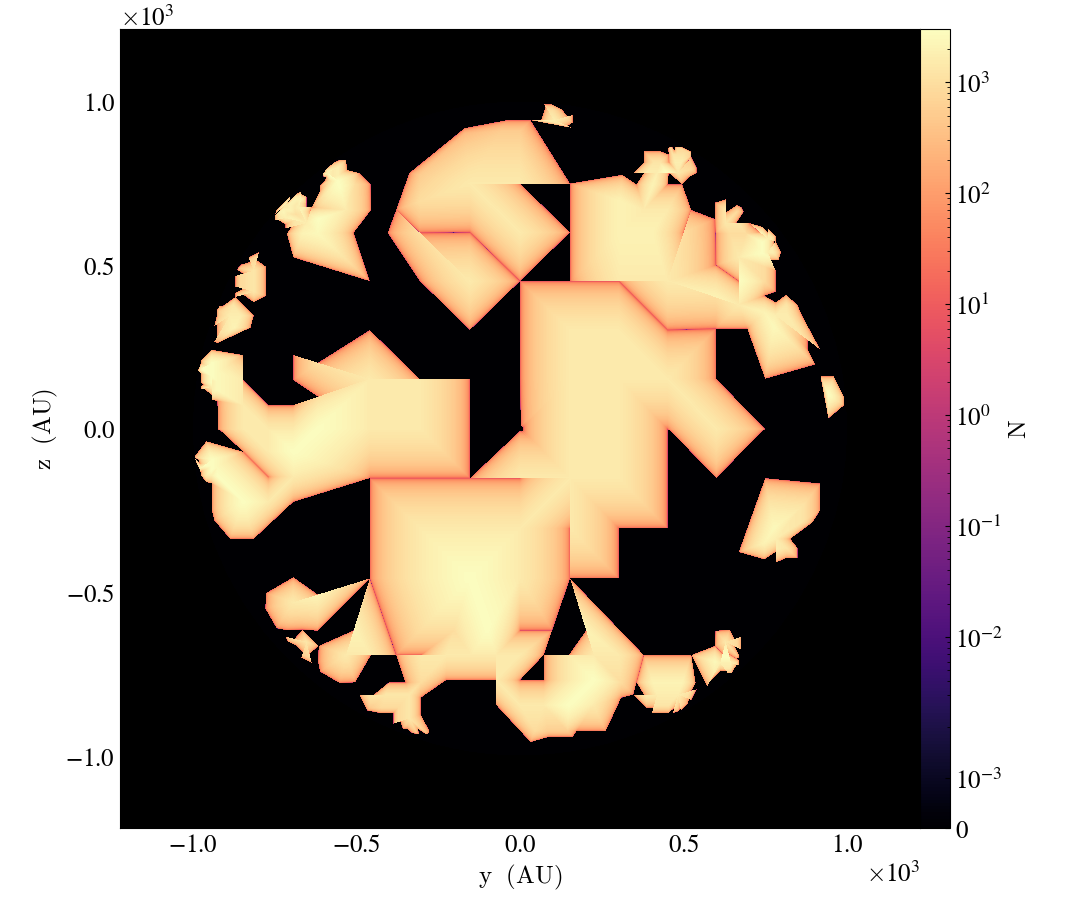

In [17]:
sl = yt.SlicePlot (ds, 'x', ('connect1', 'n'))
sl.set_cmap       (('connect1', 'n'), 'magma')
sl.zoom           (0.9)

Show meshes on the plots.


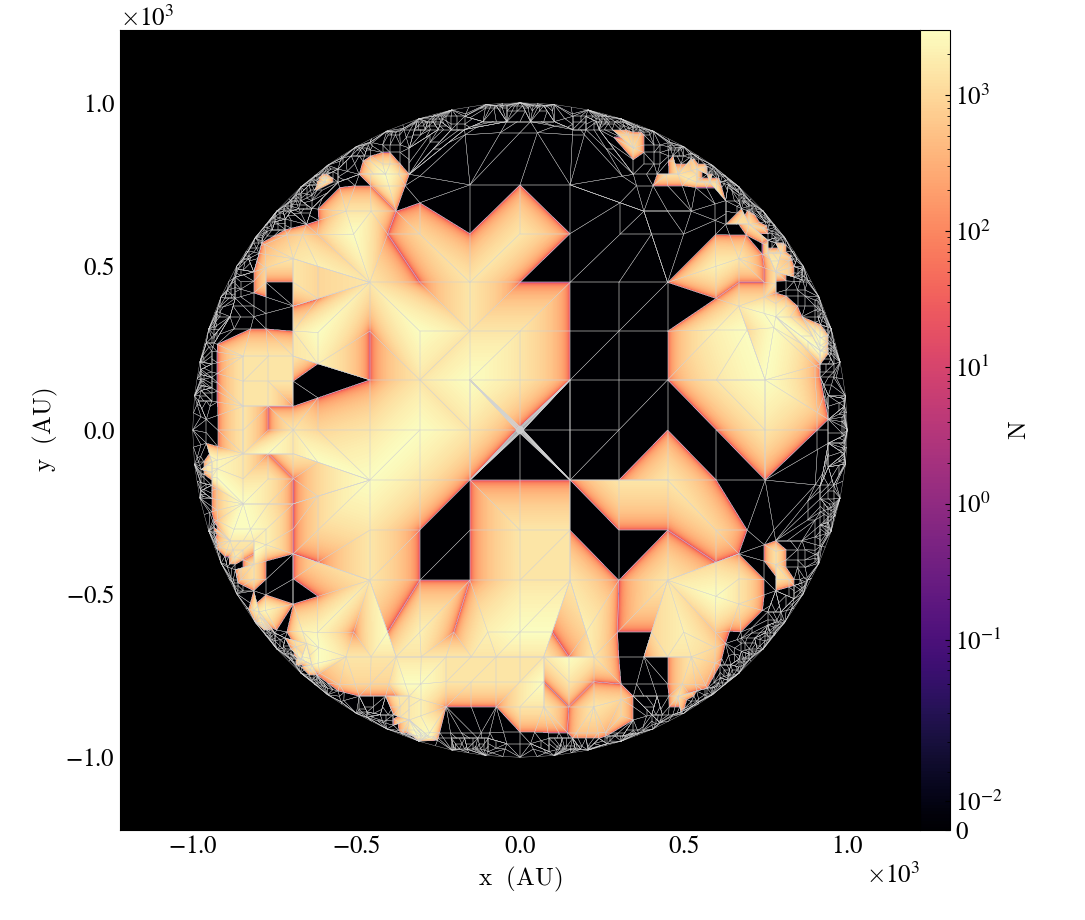

In [18]:
sl = yt.SlicePlot      (ds, 'z', ('connect1', 'n'))
sl.set_cmap            (('connect1', 'n'), 'magma')
sl.zoom                (0.9)
sl.annotate_mesh_lines (plot_args={'color':'lightgrey', 'linewidths':[.25]})


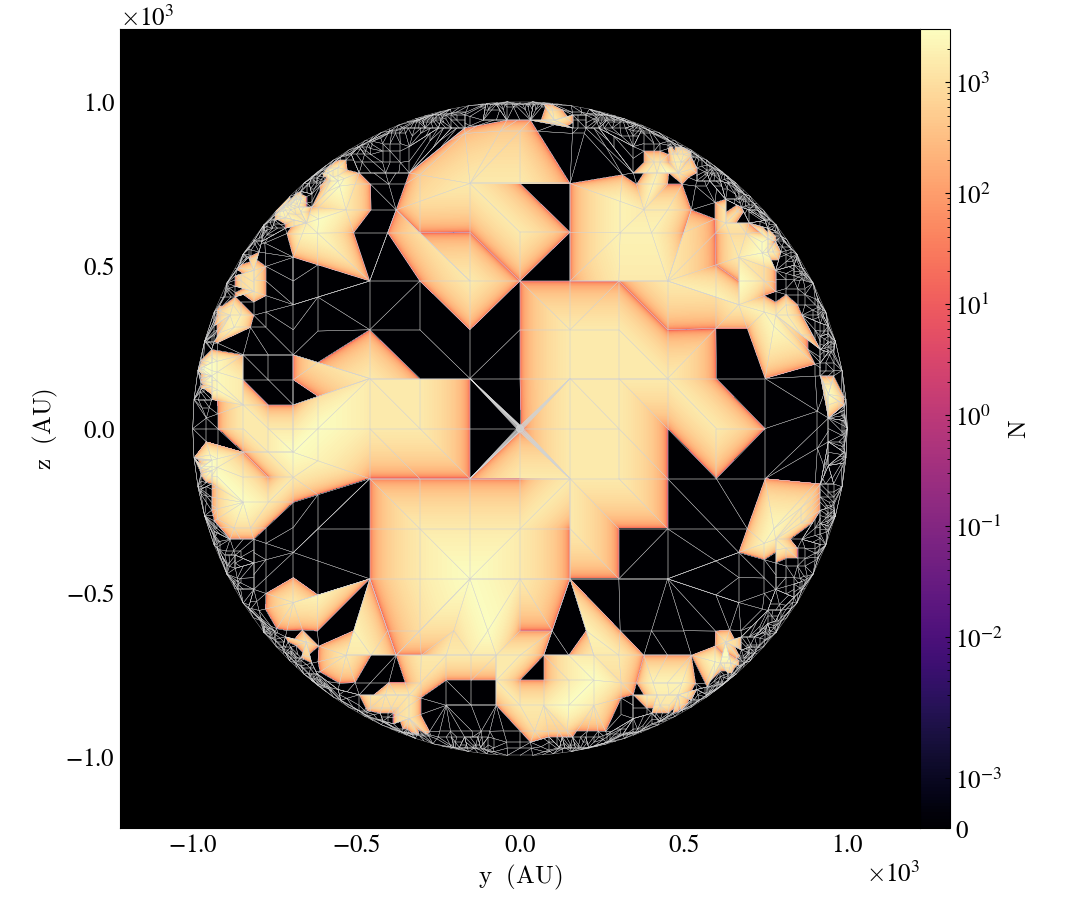

In [19]:
sl = yt.SlicePlot      (ds, 'x', ('connect1', 'n'))
sl.set_cmap            (('connect1', 'n'), 'magma')
sl.zoom                (0.9)
sl.annotate_mesh_lines (plot_args={'color':'lightgrey', 'linewidths':[.25]})

In [20]:
print(max(nNH3))


2999.9999999999995


In [21]:
print(centers)

[[-8.15799009e+13 -5.48251244e+13  8.89704785e+13]
 [ 5.27346469e+13 -3.25795587e+13 -5.00213608e+13]
 [ 2.94135604e+13 -9.37277976e+13  5.16878727e+13]
 ...
 [ 9.72074964e+13  1.20887833e+13 -1.01866373e+13]
 [ 2.98977500e+13 -1.46203322e+13 -7.11656141e+13]
 [-1.59658707e+13 -1.15560282e+14 -4.78803649e+13]]
